# LAB 6 - Xây dựng mạng Nơ-ron sâu với Fashion-MNIST

Sử dụng TensorFlow/Keras để phân loại 10 loại quần áo trong bộ dữ liệu Fashion-MNIST.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
x_train=x_train/255.0
x_test=x_test/255.0
print(x_train.shape,x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (10000, 28, 28)


In [2]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
history=model.fit(
    x_train,y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8139 - loss: 0.5222 - val_accuracy: 0.8564 - val_loss: 0.4011
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8629 - loss: 0.3723 - val_accuracy: 0.8620 - val_loss: 0.3758
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8727 - loss: 0.3419 - val_accuracy: 0.8659 - val_loss: 0.3640
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8846 - loss: 0.3106 - val_accuracy: 0.8688 - val_loss: 0.3493
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8901 - loss: 0.2937 - val_accuracy: 0.8741 - val_loss: 0.3366
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8958 - loss: 0.2779 - val_accuracy: 0.8823 - val_loss: 0.3302
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8998 - loss: 0.2640 - val_accuracy: 0.8736 - val_loss: 0.3549
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9056 - loss: 0.2546 - val_accuracy: 0.

In [4]:
loss,acc=model.evaluate(x_test,y_test,verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {acc:.4f}')


Test Loss: 0.3426
Test Accuracy: 0.8820


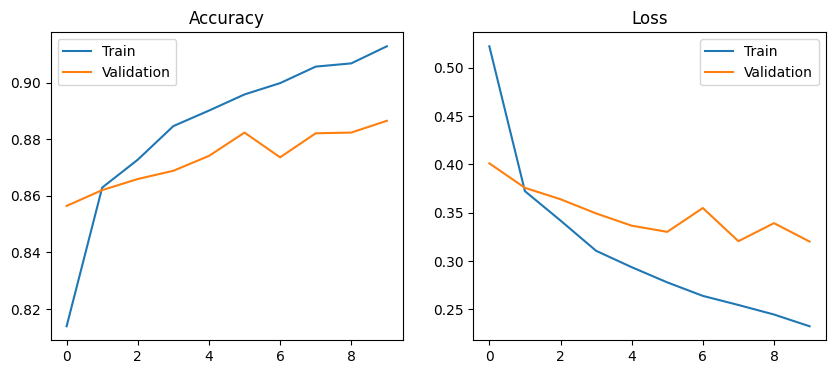

In [5]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.title('Loss')
plt.legend()
plt.show()


In [6]:
pred=model.predict(x_test)
y_pred=pred.argmax(axis=1)
print(classification_report(y_test,y_pred))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1000
           1       1.00      0.96      0.98      1000
           2       0.74      0.85      0.79      1000
           3       0.87      0.91      0.89      1000
           4       0.81      0.81      0.81      1000
           5       0.98      0.96      0.97      1000
           6       0.71      0.67      0.69      1000
           7       0.94      0.96      0.95      1000
           8       0.99      0.96      0.97      1000
           9       0.95      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



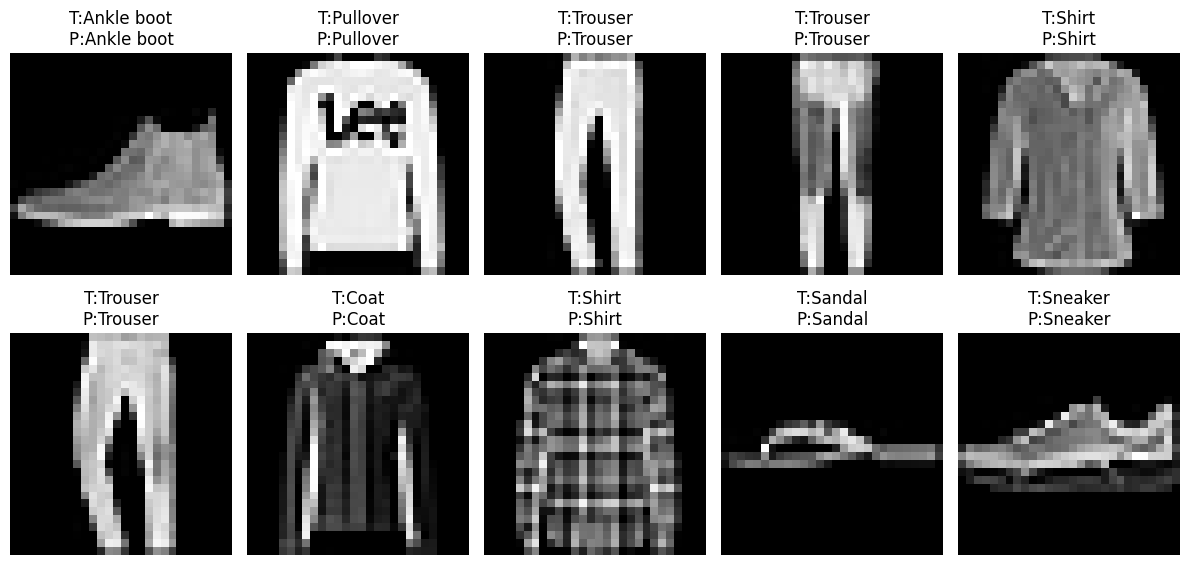

In [7]:
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat',
             'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i],cmap='gray')
    plt.title(f'T:{class_names[y_test[i]]}\nP:{class_names[y_pred[i]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()
